In [1]:
import yfinance as yf

ModuleNotFoundError: No module named 'yfinance'

In [2]:
import sys
!{sys.executable} -m pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 KB 652.7 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 14.4 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 KB 5.1 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.4/153.4 KB 1.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 KB 769.4 kB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 KB 2.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 KB 713.1 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 KB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 KB 388.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 KB 1.6 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [16]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt 

In [10]:
apple = yf.download("AAPL", start="2018-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [11]:
print(apple.head())

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.267078  40.276431  39.565806  39.776190  102223600
2018-01-03  40.260067  40.802386  40.196955  40.330195  118071600
2018-01-04  40.447086  40.549940  40.225017  40.332544   89738400
2018-01-05  40.907581  40.994071  40.451755  40.542920   94640000
2018-01-08  40.755634  41.050168  40.657453  40.755634   82271200


In [12]:
# Le 2 janvier 2018, l'action Apple ouvrait à 39,77$, a atteint un max de 40,28$
# a atteint un min de 39,57$, a clôturé à 40,27$ 
# avec 102 millions d'actions échangées 

In [13]:
apple["return"] = apple["Close"].pct_change()

In [14]:
apple["cum_return"]=(1+apple["return"]).cumprod()

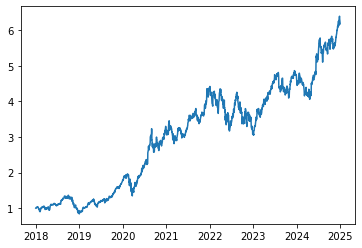

In [17]:
plt.plot(apple["cum_return"])

In [18]:
#Idée du Momentum : Si l'action monte depuis des mois alors on achète
# Si elle baisse alors on vend 

In [19]:
apple["momentum"] = (apple["Close"].pct_change(120)) #calcul du signal

In [20]:
apple["signal"] = (apple["momentum"]>0)

In [21]:
apple["strategy_return"] = (apple["signal"].shift(1)*apple["return"])

In [22]:
apple["strategy_cum"] = (1+apple["strategy_return"]).cumprod()

Comparaison au Buy & Hold

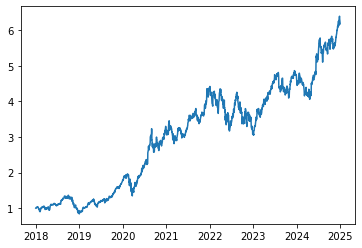

In [23]:
plt.plot(apple["cum_return"])

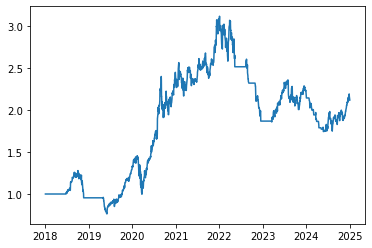

In [24]:
plt.plot(apple["strategy_cum"])

In [26]:
strategy_return = apple["return"].dropna()

Calcul du Sharpe Ratio

In [35]:
sharpe = (strategy_return.mean() / strategy_return.std()) * np.sqrt(252)

In [36]:
print(sharpe)

1.0068116528124853


Calcul le Drawdown 

In [30]:
strategy_cum = (1+strategy_return).cumprod()

In [31]:
rolling_max = strategy_cum.cummax()

In [32]:
drawdown = strategy_cum/rolling_max-1

In [33]:
max_drawdown = drawdown.min()

In [34]:
print(max_drawdown)

-0.3851593387990795


Max Drawdown : -38.52%


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

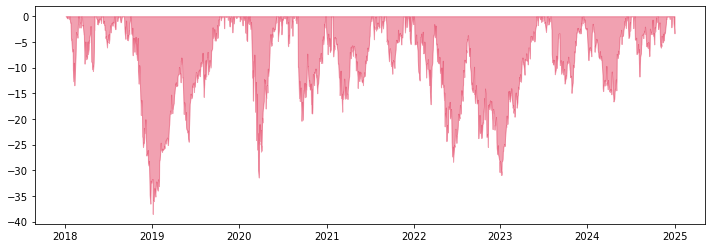

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Affichage Max Drawdown
print(f"Max Drawdown : {max_drawdown:.2%}")

# Graphique du Drawdown
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(drawdown.index, drawdown * 100, 0, color='crimson', alpha=0.4)
ax.plot(drawdown.index, drawdown * 100, color='crimson', linewidth=1)
ax.set_title("Drawdown d'Apple (AAPL)", fontsize=14, fontweight='bold')
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
import scipy.stats as stats

confidence = 0.95

# VaR historique
VaR_hist = np.percentile(strategy_return, (1 - confidence) * 100)

# Expected Shortfall (CVaR) historique
ES_hist = strategy_return[strategy_return <= VaR_hist].mean()

# VaR paramétrique (loi normale)
mu = strategy_return.mean()
sigma = strategy_return.std()
VaR_param = stats.norm.ppf(1 - confidence, mu, sigma)

print(f"VaR historique (95%)     : {VaR_hist:.2%}")
print(f"VaR paramétrique (95%)   : {VaR_param:.2%}")
print(f"Expected Shortfall (95%) : {ES_hist:.2%}")

VaR historique (95%)     : -2.95%
VaR paramétrique (95%)   : -3.04%
Expected Shortfall (95%) : -4.37%


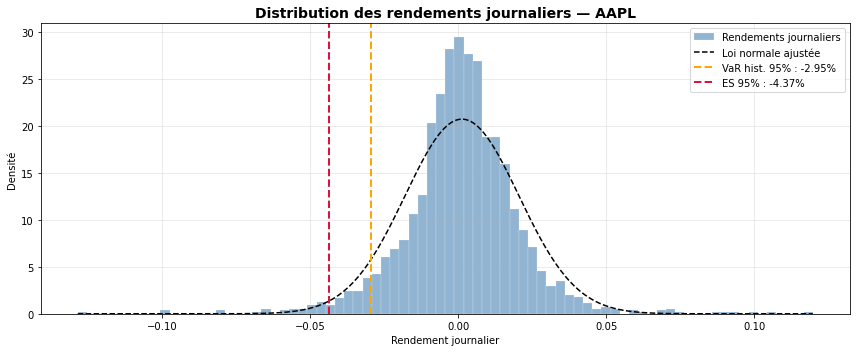

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(strategy_return, bins=80, color='steelblue', alpha=0.6,
        edgecolor='white', linewidth=0.3, density=True, label='Rendements journaliers')

# Courbe normale ajustée
x = np.linspace(strategy_return.min(), strategy_return.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=1.5, label='Loi normale ajustée')

# VaR et ES
ax.axvline(VaR_hist, color='orange', linewidth=2, linestyle='--',
           label=f'VaR hist. 95% : {VaR_hist:.2%}')
ax.axvline(ES_hist, color='crimson', linewidth=2, linestyle='--',
           label=f'ES 95% : {ES_hist:.2%}')

ax.set_title("Distribution des rendements journaliers — AAPL", fontsize=14, fontweight='bold')
ax.set_xlabel("Rendement journalier")
ax.set_ylabel("Densité")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
import pandas as pd

sharpe_annualise = (mu / sigma) * np.sqrt(252)
rendement_annualise = (1 + mu) ** 252 - 1
vol_annualisee = sigma * np.sqrt(252)

metrics = {
    "Rendement annualisé"        : f"{rendement_annualise:.2%}",
    "Volatilité annualisée"      : f"{vol_annualisee:.2%}",
    "Sharpe Ratio (annualisé)"   : f"{sharpe_annualise:.4f}",
    "Max Drawdown"               : f"{max_drawdown:.2%}",
    "VaR historique (95%)"       : f"{VaR_hist:.2%}",
    "VaR paramétrique (95%)"     : f"{VaR_param:.2%}",
    "Expected Shortfall (95%)"   : f"{ES_hist:.2%}",
}

df_metrics = pd.DataFrame.from_dict(metrics, orient='index', columns=['Valeur'])
df_metrics.index.name = "Indicateur"

# Rendu HTML sans jinja2
from IPython.display import display, HTML

html = df_metrics.to_html()
styled_html = f"""
<style>
  table {{ border-collapse: collapse; width: 50%; font-family: Arial; }}
  caption {{ font-size: 14px; font-weight: bold; margin-bottom: 8px; }}
  th {{ background-color: #2c3e50; color: white; padding: 8px 12px; text-align: left; }}
  td {{ padding: 7px 12px; text-align: right; border-bottom: 1px solid #ddd; }}
  tr:hover {{ background-color: #f5f5f5; }}
</style>
<caption>Tableau de synthèse — AAPL Risk Analysis</caption>
{html}
"""
display(HTML(styled_html))

,Valeur
Indicateur,
Rendement annualisé,35.98%
Volatilité annualisée,30.55%
Sharpe Ratio (annualisé),1.0068
Max Drawdown,-38.52%
VaR historique (95%),-2.95%
VaR paramétrique (95%),-3.04%
Expected Shortfall (95%),-4.37%


In [45]:
Rendement annualisé   →  "Combien je gagne ?"
Volatilité            →  "De combien ça fluctue ?"
Sharpe Ratio          →  "Est-ce que ça vaut le risque pris ?"
Max Drawdown          →  "Quelle est la pire perte historique ?"
VaR (95%)             →  "Quelle est ma perte normale un mauvais jour ?"
Expected Shortfall    →  "Quelle est ma perte lors d'un jour catastrophique ?"

SyntaxError: invalid character '→' (U+2192) (1314054413.py, line 1)